LIBRARY'S


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [7]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\katur
['.anaconda', '.android', '.antigravity', '.bash_history', '.claude', '.claude.json', '.conda', '.continuum', '.copilot', '.dist', '.emulator_console_auth_token', '.gemini', '.git-for-windows-updater', '.gitconfig', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.node_repl_history', '.python_history', '.redhat', '.ssh', '.VirtualBox', '.vscode', '.vscode-shared', 'AI_Based_Hiring_Prediction.ipynb', 'AndroidStudioProjects', 'AppData', 'Application Data', 'blog-nexuses', 'blog-portal', 'blog_portal', 'Contacts', 'Cookies', 'CrossDevice', 'Documents', 'Downloads', 'Favorites', 'Hiring-Dataset.csv.csv', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContain

In [8]:
df=pd.read_csv("Hiring-dataset.csv.csv")

In [9]:
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [11]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [12]:
df.shape

(1000, 11)

In [13]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [14]:
df.isnull().sum()

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

In [15]:
df["Certifications"] = df["Certifications"].fillna(df["Certifications"].mode()[0])

In [16]:
df.isnull().sum()

Resume_ID                 0
Name                      0
Skills                    0
Experience (Years)        0
Education                 0
Certifications            0
Job Role                  0
Recruiter Decision        0
Salary Expectation ($)    0
Projects Count            0
AI Score (0-100)          0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

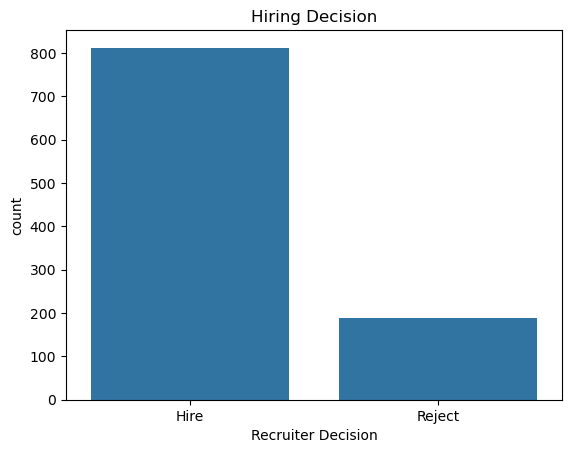

In [18]:
sns.countplot(x='Recruiter Decision', data=df)
plt.title("Hiring Decision")
plt.show()

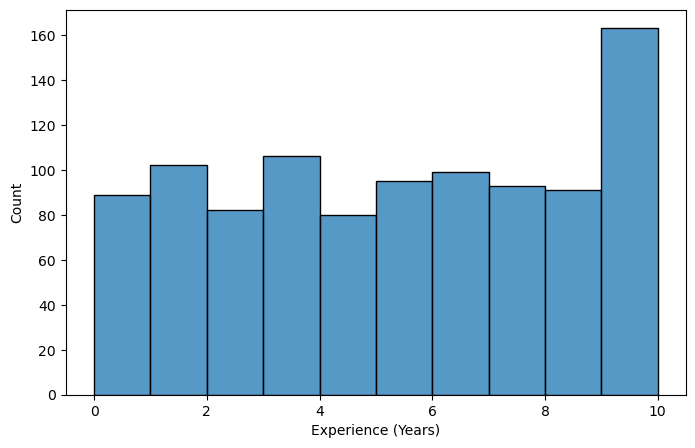

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["Experience (Years)"], bins=10)
plt.show()

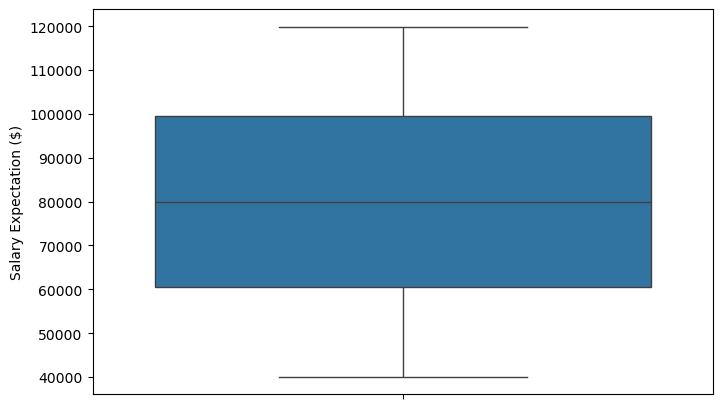

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Salary Expectation ($)"])
plt.show()

In [22]:
encoder = LabelEncoder()
cat_cols = ["Name","Skills","Education","Certifications","Job Role","Recruiter Decision"]
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [23]:
X = df.drop(["Resume_ID","Recruiter Decision"], axis=1)
y = df["Recruiter Decision"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_lr))

Accuracy: 1.0


In [29]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_dt))

Accuracy: 1.0


In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_rf))

Accuracy: 1.0


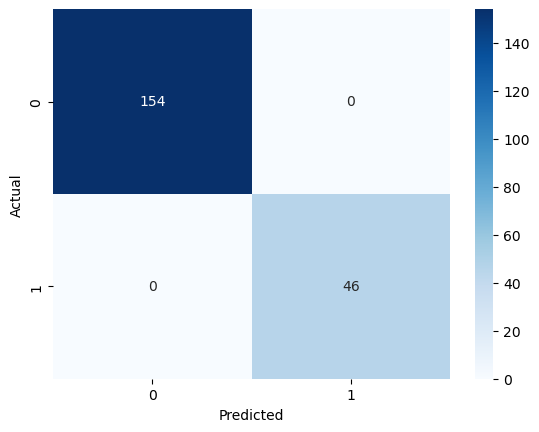

In [31]:
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



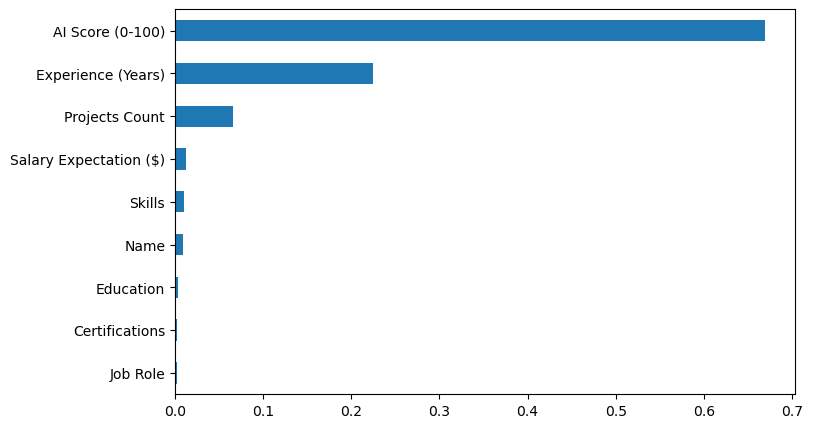

In [33]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.show()

In [34]:
df["Certifications"].mode()[0]

np.int64(1)

In [36]:
pred_rf = rf.predict(X_test)
print(pred_rf[:10])

[0 0 0 0 1 0 1 1 0 0]


In [37]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred_rf
})
comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1
5,0,0
6,1,1
7,1,1
8,0,0
9,0,0
